# U.S. Wiretap Report — Merged Dataset Analysis: 2022–2024

Annual wiretap statistics published by the U.S. Courts under 18 U.S.C. § 2519.  
This notebook merges all available tables across reporting years and produces summary statistics and charts.

**Data files:** `Data/wiretap_<table>_1231.<year>.xlsx`  
**Tables used:** 1, 3, 4, 5, 6, 7, 9, A-1, B-1


In [1]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
DATA = 'Data'
YEARS = [2022, 2023, 2024]

plt.rcParams.update({'figure.figsize': (13, 5), 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')


## 1  Load & merge all tables directly from source Excel files


In [2]:
# Table 1 — Jurisdictions with authorizing statutes (all three years)
parts = []
for yr, fname in {
    2022: 'wiretap_1_1231.2022.xlsx',
    2023: 'wiretap_1_1231.2023.xlsx',
    2024: 'wiretap_1_1231.2024.xlsx',
}.items():
    raw = pd.read_excel(f'Data/{fname}', sheet_name=0, header=None)
    # Row 0=blank, row 1=title, row 2=column headers, rows 3+ are data
    df = raw.iloc[3:].copy().reset_index(drop=True)
    df.columns = ['jurisdiction', 'statutory_citation', 'reported_use', 'orders_authorized']
    df = df[df['jurisdiction'].apply(lambda x: isinstance(x, str) and 0 < len(x.strip()) < 80)]
    df['reported_use'] = df['reported_use'].map({'Yes': True, 'No': False})
    df['orders_authorized'] = pd.to_numeric(
        df['orders_authorized'].astype(str).str.replace(',', '', regex=False), errors='coerce')
    df = df.dropna(subset=['orders_authorized'])
    df['year'] = yr
    parts.append(df[['year', 'jurisdiction', 'reported_use', 'orders_authorized']])

table1 = pd.concat(parts, ignore_index=True)
print(f'Table 1: {len(table1):,} rows | years: {sorted(table1.year.unique())}')
table1.head(3)


Table 1: 146 rows | years: [np.int64(2022), np.int64(2023), np.int64(2024)]


,year,jurisdiction,reported_use,orders_authorized
0,2022,FEDERAL,True,1274
1,2022,ALASKA,NaN,0
2,2022,ARIZONA,True,3


In [3]:
# Table 3 — Major offense categories (2022 and 2023; 2024 not yet published)
OFFENSE_COLS = ['total', 'conspiracy', 'corruption', 'gambling',
                'homicide_assault', 'kidnapping', 'larceny_theft_robbery',
                'narcotics', 'racketeering', 'other']
parts = []
for yr, fname in {
    2022: 'wiretap_3_1231.2022.xlsx',
    2023: 'wiretap_3_1231.2023.xlsx',
}.items():
    raw = pd.read_excel(f'Data/{fname}', sheet_name=0, header=None)
    # Row 2 = headers, rows 3+ = data
    df = raw.iloc[3:].copy().reset_index(drop=True)
    df.columns = ['jurisdiction'] + OFFENSE_COLS
    df = df[df['jurisdiction'].apply(lambda x: isinstance(x, str) and 0 < len(x.strip()) < 80)]
    for col in OFFENSE_COLS:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(',', '', regex=False).str.replace('-', '0', regex=False),
            errors='coerce')
    df = df.dropna(subset=['total'])
    df['year'] = yr
    parts.append(df)

table3 = pd.concat(parts, ignore_index=True)
print(f'Table 3: {len(table3):,} rows | years: {sorted(table3.year.unique())}')
table3.head(3)


Table 3: 417 rows | years: [np.int64(2022), np.int64(2023)]


,jurisdiction,total,conspiracy,corruption,gambling,homicide_assault,kidnapping,larceny_theft_robbery,narcotics,racketeering,other,year
0,Total,2406,278,14,3,110,4,3,1225,56,713,2022
1,Federal Total,1274,226,3,0,4,2,0,546,28,465,2022
2,ALABAMA MIDDLE,6,2,0,0,0,0,0,4,0,0,2022


In [4]:
# Table 4 — Interception volume summary (2022 and 2023)
# Multi-row header: rows 2–3 describe columns; data starts at row 4
parts = []
for yr, fname in {
    2022: 'wiretap_4_1231.2022.xlsx',
    2023: 'wiretap_4_1231.2023.xlsx',
}.items():
    raw = pd.read_excel(f'Data/{fname}', sheet_name=0, header=None)
    df = raw.iloc[4:].copy().reset_index(drop=True)
    df = df.iloc[:, :6]
    df.columns = ['jurisdiction', 'num_authorized', 'orders_installed',
                  'avg_persons_intercepted', 'avg_intercepts', 'avg_incriminating']
    df = df[df['jurisdiction'].apply(lambda x: isinstance(x, str) and 0 < len(x.strip()) < 80)]
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=['num_authorized'])
    df['year'] = yr
    parts.append(df)

table4 = pd.concat(parts, ignore_index=True)
print(f'Table 4: {len(table4):,} rows | years: {sorted(table4.year.unique())}')
table4.head(3)


Table 4: 418 rows | years: [np.int64(2022), np.int64(2023)]


,jurisdiction,num_authorized,orders_installed,avg_persons_intercepted,avg_intercepts,avg_incriminating,year
0,Total,2406,1992.0,184.1,5503.4,999.7,2022
1,Federal Total,1274,957.0,125.0,4971.0,801.3,2022
2,ALABAMA MIDDLE,6,4.0,335.0,NaN,NaN,2022


In [5]:
# Table 5 — Average cost per order (all three years)
# The 2022 file has a correction note at row 0; find the header row dynamically
parts = []
for yr, fname in {
    2022: 'wiretap_5_1231.2022_0.xlsx',
    2023: 'wiretap_5_1231.2023.xlsx',
    2024: 'wiretap_5_1231.2024.xlsx',
}.items():
    raw = pd.read_excel(f'Data/{fname}', sheet_name=0, header=None)
    hrow = next(i for i, r in raw.iterrows() if 'Reporting Jurisdiction' in str(r.iloc[0]))
    df = raw.iloc[hrow + 1:].copy().reset_index(drop=True)
    df.columns = ['jurisdiction', 'orders_installed', 'orders_cost_reported', 'avg_cost']
    df = df[df['jurisdiction'].apply(lambda x: isinstance(x, str) and 0 < len(x.strip()) < 80)]
    for col in ['orders_installed', 'orders_cost_reported', 'avg_cost']:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(',', '', regex=False), errors='coerce')
    df = df.dropna(subset=['orders_installed'])
    df['year'] = yr
    parts.append(df)

table5 = pd.concat(parts, ignore_index=True)
print(f'Table 5: {len(table5):,} rows | years: {sorted(table5.year.unique())}')
table5.head(3)


Table 5: 592 rows | years: [np.int64(2022), np.int64(2023), np.int64(2024)]


,jurisdiction,orders_installed,orders_cost_reported,avg_cost,year
0,Total,1992.0,1446.0,97752.0,2022
1,Federal Total,957.0,733.0,97022.0,2022
2,ALABAMA MIDDLE,4.0,3.0,97732.0,2022


In [6]:
# Table 6 — Surveillance types, arrests, and convictions (all three years)
# Row 2 = headers; row 3 = TOTAL aggregate; section-header rows have no numeric order count
parts = []
for yr, fname in {
    2022: 'wiretap_6_1231.2022.xlsx',
    2023: 'wiretap_6_1231.2023.xlsx',
    2024: 'wiretap_6_1231.2024.xlsx',
}.items():
    raw = pd.read_excel(f'Data/{fname}', sheet_name=0, header=None)
    df = raw.iloc[3:].copy().reset_index(drop=True)
    df = df.iloc[:, :8]
    df.columns = ['jurisdiction', 'orders_installed', 'wire', 'oral',
                  'electronic', 'combination', 'persons_arrested', 'persons_convicted']
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=['orders_installed'])  # drops blank section-header rows
    df = df[df['jurisdiction'].apply(lambda x: isinstance(x, str) and 0 < len(x.strip()) < 80)]
    df['year'] = yr
    parts.append(df)

table6 = pd.concat(parts, ignore_index=True)
print(f'Table 6: {len(table6):,} rows | years: {sorted(table6.year.unique())}')
table6.head(3)


Table 6: 594 rows | years: [np.int64(2022), np.int64(2023), np.int64(2024)]

,jurisdiction,orders_installed,wire,oral,electronic,combination,persons_arrested,persons_convicted,year
0,TOTAL,1992.0,1054.0,18.0,42.0,878.0,5287.0,548.0,2022
1,FEDERAL TOTAL,957.0,486.0,5.0,30.0,436.0,2525.0,181.0,2022
2,ALABAMA MIDDLE,4.0,2.0,0.0,0.0,2.0,0.0,0.0,2022


In [7]:
# Tables A-1 + B-1 — Individual intercept orders: federal district courts and state courts
# Row 2 = column headers in both files; rows 3+ = one order per row
ORDER_NUM_COLS = [
    'Original Order (Days)', 'Number of Extensions', 'Total Length (Days)',
    'Number of Days in Operation', 'Avg. Intercepts Per Day',
    'Number of Persons Intercepts', 'Number of Intercepts',
    'Number of Incriminating Intercepts', 'Total Cost($)', 'Arrests', 'Persons Convicted'
]

parts = []

for yr, fname in {
    2022: 'wiretap_a1_1231.2022_1.xlsx',
    2023: 'wiretap_a1_1231.2023.xlsx',
    2024: 'wiretap_a1_1231.2024.xlsx',
}.items():
    raw = pd.read_excel(f'Data/{fname}', sheet_name=0, header=None)
    df = raw.iloc[3:].copy().reset_index(drop=True)
    df.columns = list(raw.iloc[2])
    df = df[df['Jurisdiction'].apply(lambda x: isinstance(x, str) and 0 < len(x.strip()) < 60)]
    df['year'] = yr
    df['court_type'] = 'Federal'
    df['state'] = df['Jurisdiction'].str.split().str[0]
    parts.append(df)

for yr, fname in {
    2022: 'wiretap_b1_1231.2022.xlsx',
    2023: 'wiretap_b1_1231.2023.xlsx',
    2024: 'wiretap_b1_1231.2024.xlsx',
}.items():
    raw = pd.read_excel(f'Data/{fname}', sheet_name=0, header=None)
    df = raw.iloc[3:].copy().reset_index(drop=True)
    df.columns = list(raw.iloc[2])
    df = df[df['State'].apply(lambda x: isinstance(x, str) and 0 < len(x.strip()) < 40)]
    df = df.rename(columns={'State': 'state'})
    df['year'] = yr
    df['court_type'] = 'State'
    parts.append(df)

orders = pd.concat(parts, ignore_index=True, sort=False)
for col in ORDER_NUM_COLS:
    if col in orders.columns:
        orders[col] = pd.to_numeric(
            orders[col].astype(str).str.replace(',', '', regex=False), errors='coerce')
orders['installed'] = orders['Installation'].str.strip().str.upper() == 'INSTALLED AND USED'

print(f'Orders (A-1 + B-1): {len(orders):,} rows')
print(f'Years: {sorted(orders.year.unique())}')
print(f'Court types: {orders.court_type.value_counts().to_dict()}')
orders.head(3)


Orders (A-1 + B-1): 10,555 rows
Years: [np.int64(2022), np.int64(2023), np.int64(2024)]
Court types: {'Federal': 7212, 'State': 3343}


,Jurisdiction,A.O. Number,Judge,Attorney General or Designee,Offense,Type,Location,Application Date,Original Order (Days),Number of Extensions,...,Motions Pending,Persons Convicted,Cost Related,Results Related,year,court_type,state,Authorizing Official,Prosecutor,installed
0,ALABAMA MIDDLE,2021-21-00734,THOMPSON,"KEVIN O. DRISCOLL, RICHARD W. DOWNING",NARCOTICS,"TX,WC",D,2021-09-17 00:00:00,30,2,...,0,0,NaN,NaN,2022,Federal,ALABAMA,NaN,NaN,False
1,ALABAMA MIDDLE,2021-22-00325,THOMPSON,NaN,CONSPIRACY,"TX,WC",D,2021-09-17 00:00:00,30,3,...,0,0,NaN,NaN,2022,Federal,ALABAMA,NaN,NaN,False
2,ALABAMA MIDDLE,2021-22-02757,THOMPSON,DANIEL KAHN,NARCOTICS,WC,D,2021-07-19 00:00:00,30,0,...,0,0,NaN,NaN,2022,Federal,ALABAMA,NaN,NaN,True


## 3  Summary overview


In [8]:
# Total orders authorised by year (Table 1, all jurisdictions)
orders_by_year = (
    table1.groupby('year')['orders_authorized'].sum().reset_index()
)

# Jurisdictions that reported any use
reporting = (
    table1.groupby('year')['reported_use']
    .agg(reported='sum', total='count')
    .assign(pct_reporting=lambda d: (d.reported.astype(float) / d.total.astype(float) * 100).round(1))
    .reset_index()
)

# Cost overview (Table 5)
cost_total = (
    table5[table5['jurisdiction'].str.upper() == 'TOTAL']
    [['year', 'orders_installed', 'orders_cost_reported', 'avg_cost']]
)

# Arrests/convictions (Table 6 TOTAL rows)
outcomes_total = (
    table6[table6['jurisdiction'].str.upper() == 'TOTAL']
    [['year', 'orders_installed', 'persons_arrested', 'persons_convicted']]
)

summary = (
    orders_by_year
    .merge(reporting[['year', 'pct_reporting']], on='year')
    .merge(cost_total[['year', 'avg_cost']], on='year', how='left')
    .merge(outcomes_total[['year', 'persons_arrested', 'persons_convicted']], on='year', how='left')
    .rename(columns={
        'orders_authorized': 'Total Orders',
        'pct_reporting': '% Jurisdictions Reporting',
        'avg_cost': 'Avg Cost/Order ($)',
        'persons_arrested': 'Persons Arrested',
        'persons_convicted': 'Persons Convicted',
    })
)
summary['Avg Cost/Order ($)'] = summary['Avg Cost/Order ($)'].apply(
    lambda x: f'${x:,.0f}' if pd.notna(x) else 'N/A'
)
summary


,year,Total Orders,% Jurisdictions Reporting,Avg Cost/Order ($),Persons Arrested,Persons Convicted
0,2022,2406,100.0,"$97,752",5287.0,548.0
1,2023,2101,100.0,"$1,711,436",5530.0,456.0
2,2024,2297,100.0,"$80,730",5463.0,717.0


## 4  Total wiretap orders: 2022–2024


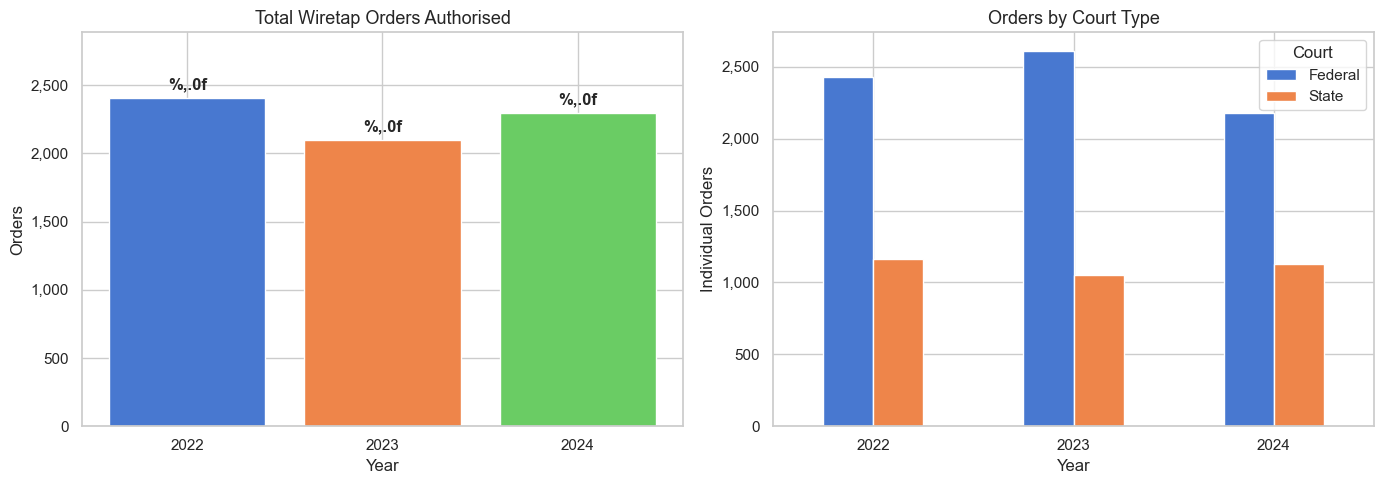

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: total orders by year
ax = axes[0]
totals = table1.groupby('year')['orders_authorized'].sum()
bars = ax.bar(totals.index.astype(str), totals.values, color=sns.color_palette('muted')[:3], edgecolor='white')
ax.bar_label(bars, fmt='%,.0f', padding=4, fontsize=12, fontweight='bold')
ax.set_title('Total Wiretap Orders Authorised', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Orders')
ax.set_ylim(0, totals.max() * 1.2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Right: federal vs state split (from orders detail dataset)
ax = axes[1]
split = orders.groupby(['year', 'court_type']).size().unstack(fill_value=0)
split.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Orders by Court Type', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Individual Orders')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Court')

plt.tight_layout()
plt.savefig('analysis_orders_trend.png', dpi=150, bbox_inches='tight')
plt.show()


## 5  Jurisdiction analysis

Which states issue the most orders? Which newly started or stopped reporting?


In [10]:
exclude = {'FEDERAL', 'TOTAL', 'TOTAL ALL JURISDICTIONS'}
jur_totals = (
    table1[~table1['jurisdiction'].str.upper().isin(exclude)]
    .groupby('jurisdiction')['orders_authorized'].sum()
    .sort_values(ascending=False)
    .head(15)
)
jur_totals.head()

jurisdiction
CALIFORNIA        1296
NEW YORK           390
NEVADA             224
FLORIDA            209
NORTH CAROLINA     201
Name: orders_authorized, dtype: int64

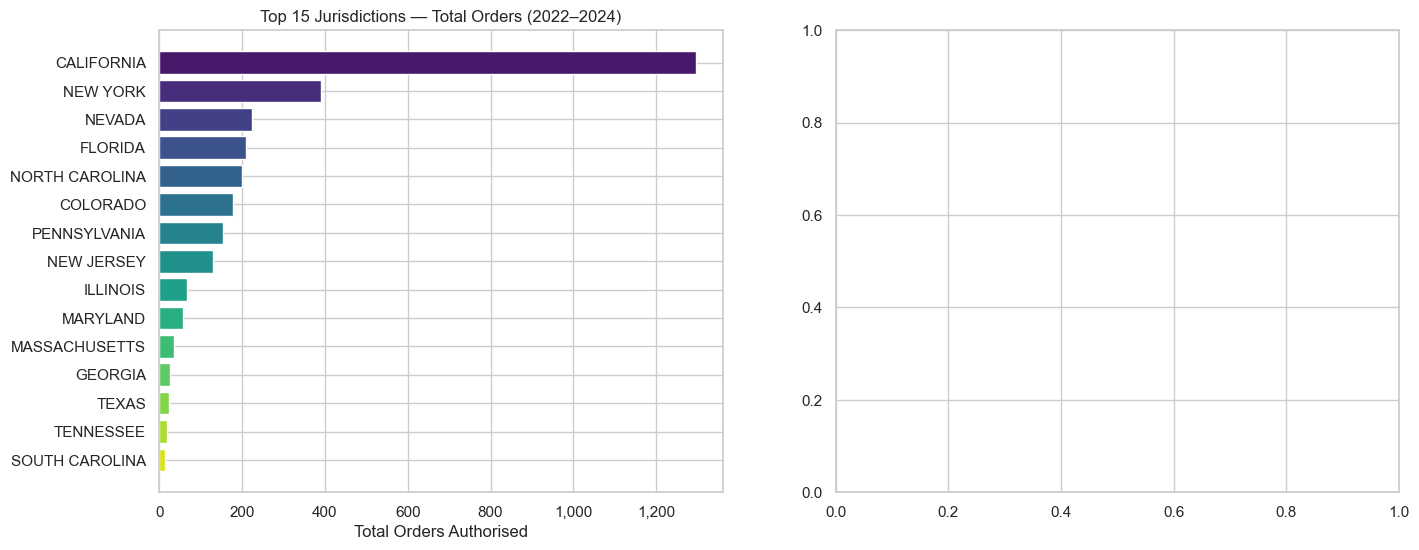

In [11]:



fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 bar chart
ax = axes[0]
colors = sns.color_palette('viridis', len(jur_totals))
ax.barh(jur_totals.index[::-1], jur_totals.values[::-1], color=colors[::-1])
ax.set_title('Top 15 Jurisdictions — Total Orders (2022–2024)', fontsize=12)
ax.set_xlabel('Total Orders Authorised')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))



In [12]:
# Year-over-year change per jurisdiction (pivot Table 1)
t1_pivot = (
    table1[~table1['jurisdiction'].str.upper().isin(exclude)]
    .pivot_table(index='jurisdiction', columns='year', values='orders_authorized', fill_value=0)
)
t1_pivot.columns = [str(c) for c in t1_pivot.columns]

if '2022' in t1_pivot.columns and '2024' in t1_pivot.columns:
    t1_pivot['change_22_24'] = t1_pivot['2024'] - t1_pivot['2022']
    biggest_gains = t1_pivot.nlargest(10, 'change_22_24')[['2022', '2023', '2024', 'change_22_24']]
    biggest_drops = t1_pivot.nsmallest(10, 'change_22_24')[['2022', '2023', '2024', 'change_22_24']]
    print('--- Biggest increases in orders (2022 → 2024) ---')
    display(biggest_gains)
    print('--- Biggest decreases in orders (2022 → 2024) ---')
    display(biggest_drops)


--- Biggest increases in orders (2022 → 2024) ---


,2022,2023,2024,change_22_24
jurisdiction,,,,
NEW YORK,106.0,146.0,138.0,32.0
TEXAS,2.0,3.0,18.0,16.0
MARYLAND,12.0,22.0,24.0,12.0
SOUTH CAROLINA,0.0,3.0,12.0,12.0
ILLINOIS,17.0,24.0,26.0,9.0
ALABAMA,0.0,0.0,8.0,8.0
NEVADA,85.0,46.0,93.0,8.0
FLORIDA,73.0,56.0,80.0,7.0
UTAH,0.0,7.0,6.0,6.0


--- Biggest decreases in orders (2022 → 2024) ---


,2022,2023,2024,change_22_24
jurisdiction,,,,
CALIFORNIA,467.0,463.0,366.0,-101.0
NORTH CAROLINA,94.0,68.0,39.0,-55.0
PENNSYLVANIA,70.0,51.0,33.0,-37.0
MASSACHUSETTS,23.0,12.0,1.0,-22.0
NEW JERSEY,66.0,12.0,51.0,-15.0
TENNESSEE,14.0,2.0,4.0,-10.0
MINNESOTA,4.0,0.0,0.0,-4.0
GEORGIA,11.0,8.0,8.0,-3.0
MICHIGAN,2.0,0.0,0.0,-2.0


## 6  Offense type breakdown

Using Table 3 (available for 2022–2023). Narcotics consistently account for ~50% of all orders.


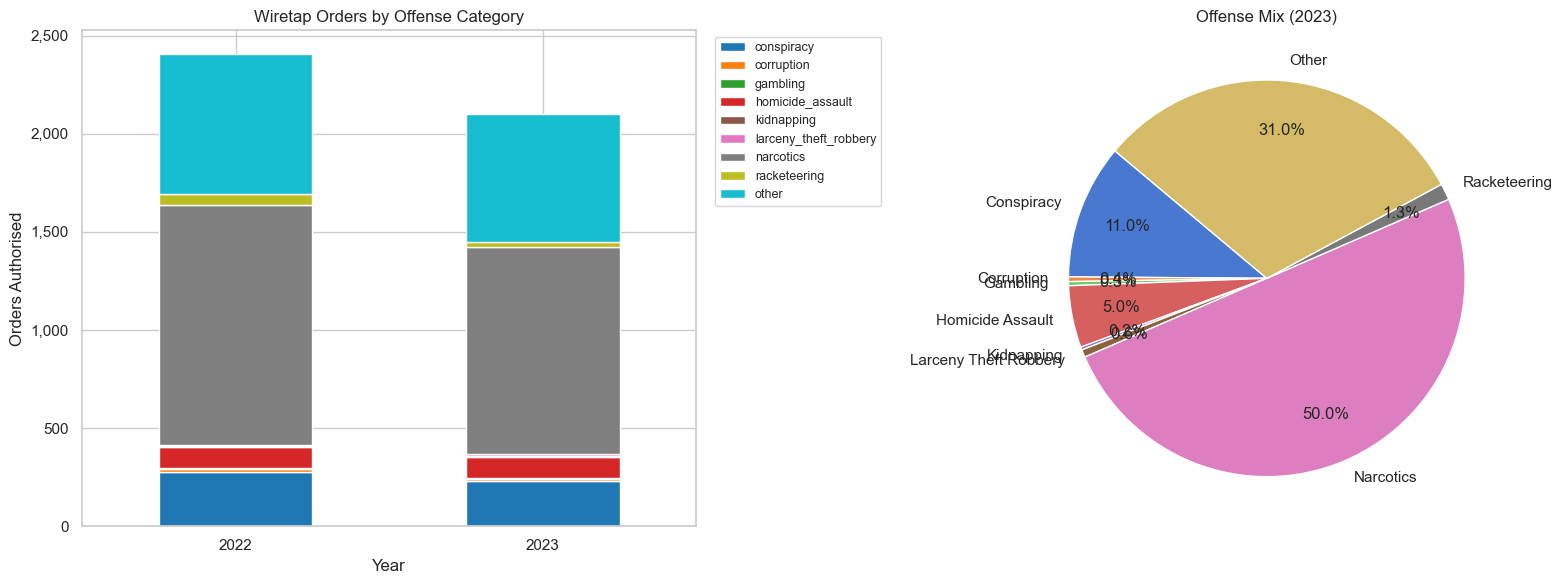

In [13]:
# National totals from Table 3
nat3 = table3[table3['jurisdiction'].str.upper() == 'TOTAL'].copy()

offense_mix = nat3.set_index('year')[OFFENSE_COLS[1:]].T

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
offense_mix.T.plot(kind='bar', stacked=True, ax=ax, edgecolor='white', colormap='tab10')
ax.set_title('Wiretap Orders by Offense Category', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel('Orders Authorised')
ax.tick_params(axis='x', rotation=0)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax = axes[1]
latest_yr = nat3['year'].max()
row = nat3[nat3['year'] == latest_yr].iloc[0]
vals = {c: row[c] for c in OFFENSE_COLS[1:] if row[c] > 0}
ax.pie(list(vals.values()),
       labels=[c.replace('_', ' ').title() for c in vals.keys()],
       autopct='%1.1f%%', startangle=140, pctdistance=0.75)
ax.set_title(f'Offense Mix ({latest_yr})', fontsize=12)

plt.tight_layout()
plt.savefig('analysis_offenses.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# National totals table
print('National offense totals (Table 3):')
nat3.set_index('year')[OFFENSE_COLS].style.format('{:,.0f}')


National offense totals (Table 3):


,total,conspiracy,corruption,gambling,homicide_assault,kidnapping,larceny_theft_robbery,narcotics,racketeering,other
year,,,,,,,,,,
2022,"2,406",278,14,3,110,4,3,"1,225",56,713
2023,"2,101",231,8,7,106,5,13,"1,051",28,652


## 7  Cost analysis


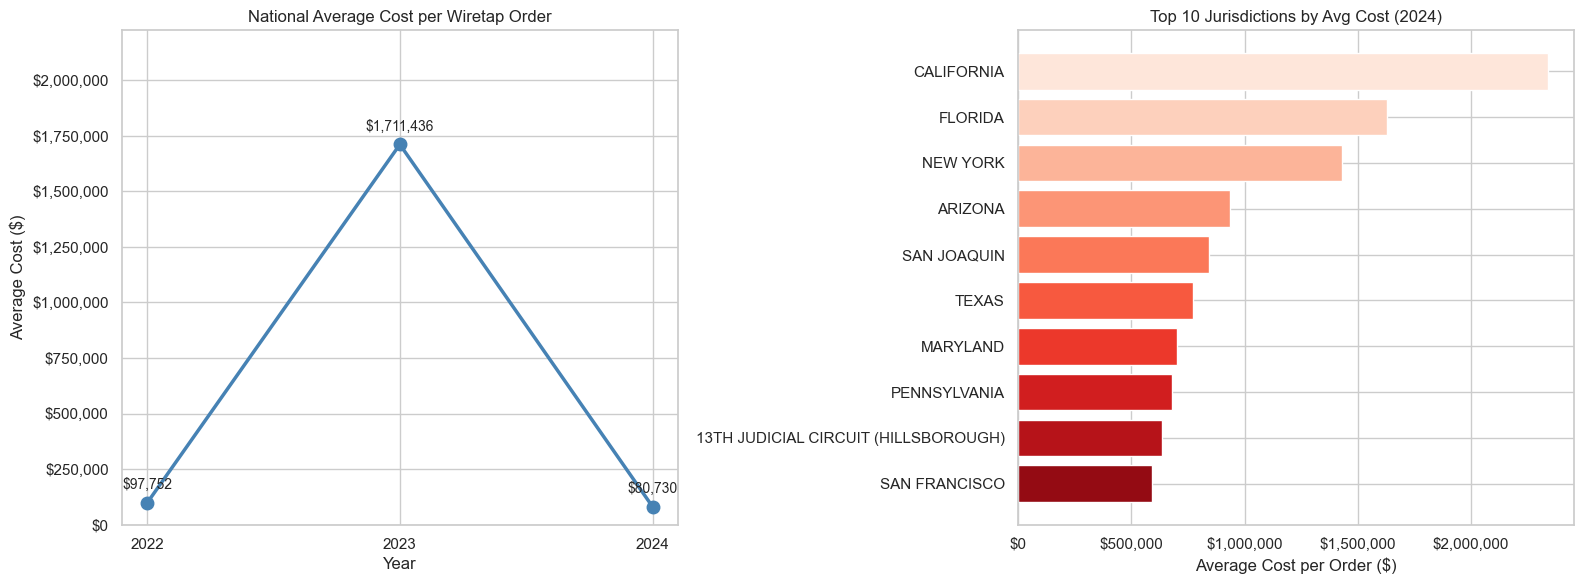

In [15]:
# National-level average cost from Table 5 'Total' rows
cost_nat = table5[table5['jurisdiction'].str.upper() == 'TOTAL'].copy()

# Top 10 most expensive jurisdictions (avg cost) — latest year
latest_cost_yr = table5['year'].max()
expensive = (
    table5[
        (table5['year'] == latest_cost_yr) &
        (~table5['jurisdiction'].str.upper().isin({'TOTAL', 'FEDERAL TOTAL'}))
    ]
    .dropna(subset=['avg_cost'])
    .sort_values('avg_cost', ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average cost trend
ax = axes[0]
ax.plot(cost_nat['year'], cost_nat['avg_cost'], marker='o', linewidth=2.5, markersize=9,
        color='steelblue')
for _, row in cost_nat.iterrows():
    ax.annotate(f"${row['avg_cost']:,.0f}", (row['year'], row['avg_cost']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=10)
ax.set_title('National Average Cost per Wiretap Order', fontsize=12)
ax.set_ylabel('Average Cost ($)')
ax.set_xlabel('Year')
ax.set_xticks([2022, 2023, 2024])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylim(0, cost_nat['avg_cost'].max() * 1.3)

# Top 10 most expensive jurisdictions
ax = axes[1]
ax.barh(expensive['jurisdiction'][::-1], expensive['avg_cost'][::-1],
        color=sns.color_palette('Reds_r', len(expensive)))
ax.set_title(f'Top 10 Jurisdictions by Avg Cost ({latest_cost_yr})', fontsize=12)
ax.set_xlabel('Average Cost per Order ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('analysis_costs.png', dpi=150, bbox_inches='tight')
plt.show()


## 8  Surveillance types, arrests, and convictions


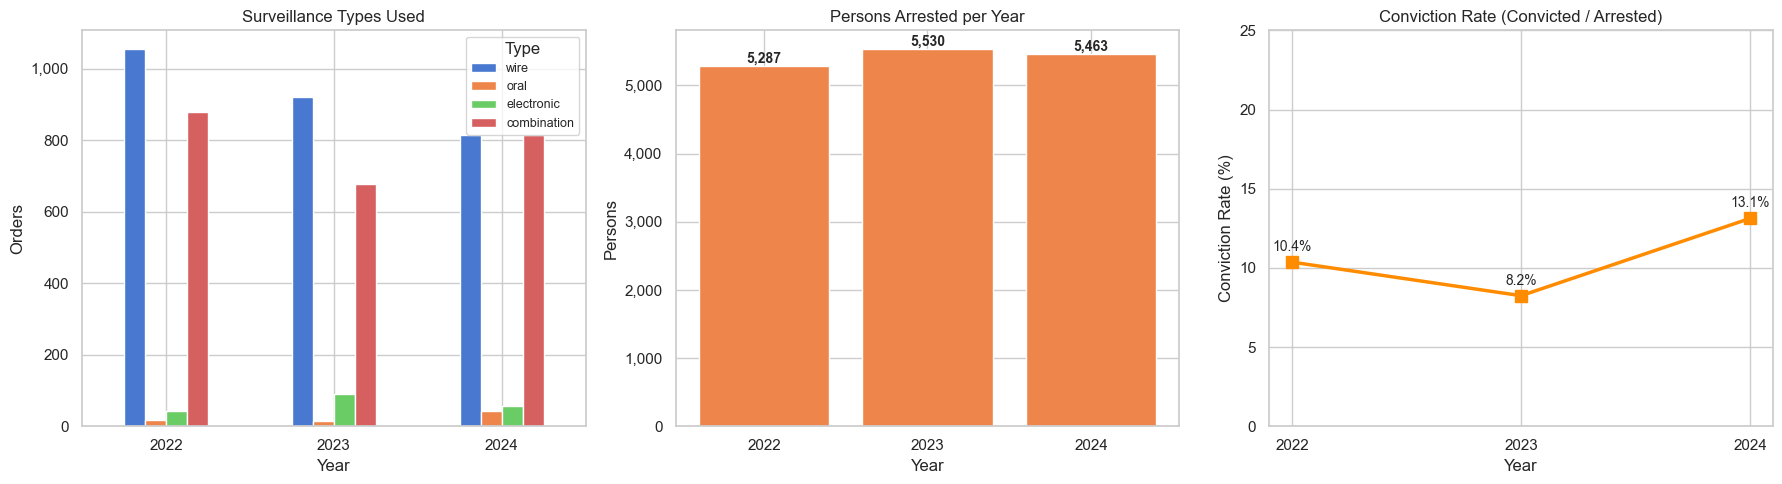

In [16]:
# National totals from Table 6
surv_nat = table6[table6['jurisdiction'].str.upper() == 'TOTAL'].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Surveillance type mix
ax = axes[0]
surv_types = surv_nat.set_index('year')[['wire', 'oral', 'electronic', 'combination']]
surv_types.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Surveillance Types Used', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel('Orders')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Type', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Arrests over time
ax = axes[1]
ax.bar(surv_nat['year'].astype(str), surv_nat['persons_arrested'],
       color=sns.color_palette('muted')[1], edgecolor='white')
ax.set_title('Persons Arrested per Year', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel('Persons')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, row in surv_nat.reset_index().iterrows():
    ax.text(i, row['persons_arrested'] + 50, f"{row['persons_arrested']:,.0f}",
            ha='center', fontsize=10, fontweight='bold')

# Conviction rate
surv_nat = surv_nat.copy()
surv_nat['conv_rate'] = surv_nat['persons_convicted'] / surv_nat['persons_arrested'] * 100
ax = axes[2]
ax.plot(surv_nat['year'], surv_nat['conv_rate'], marker='s', linewidth=2.5,
        markersize=9, color='darkorange')
for _, row in surv_nat.iterrows():
    ax.annotate(f"{row['conv_rate']:.1f}%", (row['year'], row['conv_rate']),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=10)
ax.set_title('Conviction Rate (Convicted / Arrested)', fontsize=12)
ax.set_ylabel('Conviction Rate (%)')
ax.set_xlabel('Year')
ax.set_xticks([2022, 2023, 2024])
ax.set_ylim(0, 25)

plt.tight_layout()
plt.savefig('analysis_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()


## 9  Individual order analysis (Tables A-1 + B-1)

These tables contain one row per intercept order. Together they cover ~5,000+ orders across 2022–2024.


In [17]:
print(f'Total orders (A-1 + B-1 combined): {len(orders):,}')
print(f'Installed and actually used: {orders["installed"].sum():,} ({orders["installed"].mean()*100:.1f}%)')
print()
print('Court type breakdown:')
display(orders.groupby(['year', 'court_type']).size().unstack(fill_value=0))


Total orders (A-1 + B-1 combined): 10,555
Installed and actually used: 8,925 (84.6%)

Court type breakdown:


court_type,Federal,State
year,,
2022,2428,1162
2023,2609,1050
2024,2175,1131


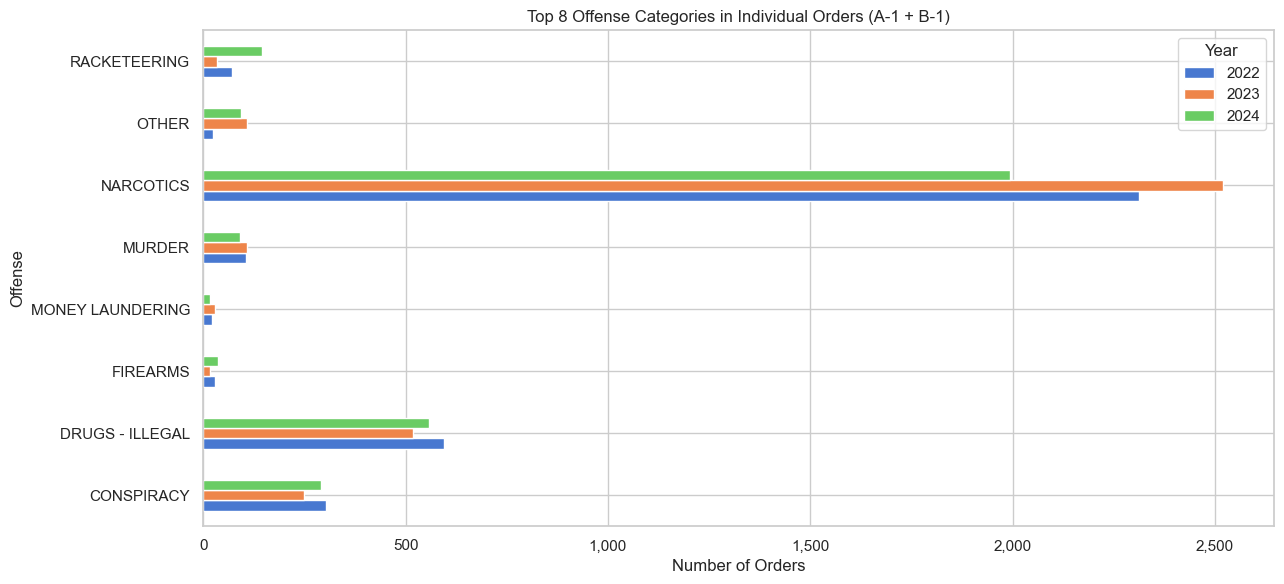

In [18]:
# Offense breakdown from individual orders
if 'Offense' in orders.columns:
    offense_counts = (
        orders.groupby(['year', 'Offense']).size().reset_index(name='count')
    )
    top_offenses = (
        offense_counts.groupby('Offense')['count'].sum()
        .sort_values(ascending=False)
        .head(8)
        .index
    )
    off_pivot = (
        offense_counts[offense_counts['Offense'].isin(top_offenses)]
        .pivot_table(index='Offense', columns='year', values='count', fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(13, 6))
    off_pivot.plot(kind='barh', ax=ax, edgecolor='white')
    ax.set_title('Top 8 Offense Categories in Individual Orders (A-1 + B-1)', fontsize=12)
    ax.set_xlabel('Number of Orders')
    ax.legend(title='Year')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.savefig('analysis_offense_detail.png', dpi=150, bbox_inches='tight')
    plt.show()


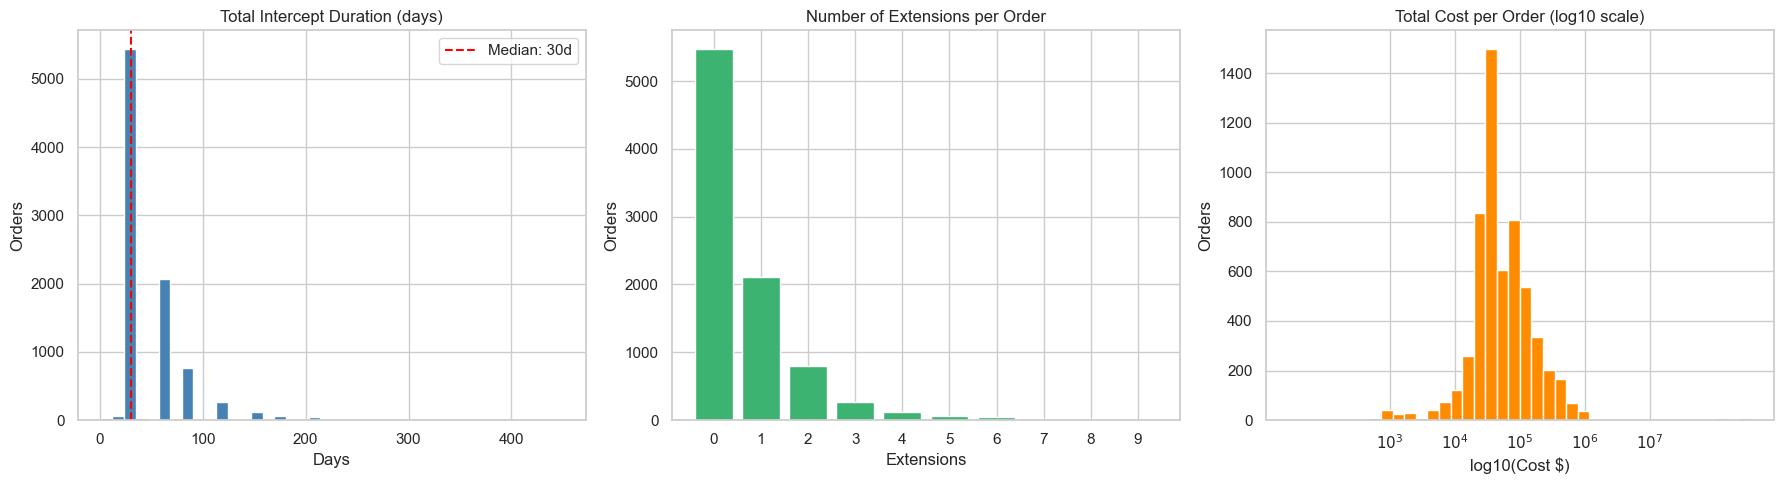

In [19]:
# Order duration and extensions
dur_col = 'Total Length (Days)'
ext_col = 'Number of Extensions'

installed_orders = orders[orders['installed']].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Duration distribution
ax = axes[0]
if dur_col in installed_orders.columns:
    dur = installed_orders[dur_col].dropna()
    dur = dur[dur.between(1, 500)]
    ax.hist(dur, bins=40, color='steelblue', edgecolor='white')
    ax.axvline(dur.median(), color='red', linestyle='--', label=f'Median: {dur.median():.0f}d')
    ax.set_title('Total Intercept Duration (days)', fontsize=12)
    ax.set_xlabel('Days')
    ax.set_ylabel('Orders')
    ax.legend()

# Extensions distribution
ax = axes[1]
if ext_col in installed_orders.columns:
    ext = installed_orders[ext_col].dropna()
    ext_vc = ext.value_counts().sort_index().head(10)
    ax.bar(ext_vc.index.astype(str), ext_vc.values, color='mediumseagreen', edgecolor='white')
    ax.set_title('Number of Extensions per Order', fontsize=12)
    ax.set_xlabel('Extensions')
    ax.set_ylabel('Orders')

# Cost distribution (log scale)
ax = axes[2]
cost_col = 'Total Cost($)'
if cost_col in installed_orders.columns:
    cost = installed_orders[cost_col].dropna()
    cost = cost[cost > 0]
    ax.hist(np.log10(cost), bins=40, color='darkorange', edgecolor='white')
    ax.set_title('Total Cost per Order (log10 scale)', fontsize=12)
    ax.set_xlabel('log10(Cost $)')
    ax.set_ylabel('Orders')
    ticks = [3, 4, 5, 6, 7]
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'$10^{t}$' for t in ticks])

plt.tight_layout()
plt.savefig('analysis_order_detail.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
# Summary stats for installed orders
stat_cols = [dur_col, ext_col, 'Number of Persons Intercepts',
             'Number of Intercepts', 'Number of Incriminating Intercepts',
             'Total Cost($)', 'Arrests']
stat_cols = [c for c in stat_cols if c in installed_orders.columns]
installed_orders[stat_cols].describe().T[['count', 'mean', '50%', 'min', 'max']].rename(
    columns={'50%': 'median'}
).style.format({'count': '{:,.0f}', 'mean': '{:,.1f}', 'median': '{:,.1f}',
                'min': '{:,.0f}', 'max': '{:,.0f}'})


,count,mean,median,min,max
Total Length (Days),"8,925",49.5,30.0,1,760
Number of Extensions,"8,925",0.7,0.0,0,26
Number of Persons Intercepts,"8,925",344.0,19.0,0,"2,084,741"
Number of Intercepts,"8,925","6,512.5",937.0,0,"4,395,109"
Number of Incriminating Intercepts,"8,925",917.1,131.0,0,"385,540"
Total Cost($),"8,925","563,075.8","25,400.0",0,"354,940,034"
Arrests,"8,925",2.7,0.0,0,110


In [21]:
# Federal vs state comparison — key metrics
compare = (
    installed_orders
    .groupby('court_type')
    .agg(
        orders=('Jurisdiction', 'count') if 'Jurisdiction' in installed_orders.columns else ('court_type', 'count'),
        median_duration=(dur_col, 'median'),
        median_extensions=(ext_col, 'median'),
        median_cost=(cost_col, 'median'),
        total_arrests=('Arrests', 'sum'),
        total_convicted=('Persons Convicted', 'sum'),
    )
)
compare


,orders,median_duration,median_extensions,median_cost,total_arrests,total_convicted
court_type,,,,,,
Federal,5996,30.0,0.0,35522.0,13513,1603
State,2929,30.0,0.0,20000.0,10297,1290


## 10  Historical trends (Table 7 — 2012 to 2024)

Table 7 provides multi-year totals reported in each annual edition (2024 edition used here).


In [22]:
# Table 7 — historical authorized intercepts
t7_raw = pd.read_excel('Data/wiretap_7_1231.2024.xlsx', sheet_name=0, header=None)

t7_cols = list(t7_raw.iloc[2])
t7 = t7_raw.iloc[3:].copy().reset_index(drop=True)
t7.columns = t7_cols
t7 = t7.rename(columns={t7.columns[0]: 'metric'})
t7 = t7[t7['metric'].apply(lambda x: isinstance(x, str) and 0 < len(str(x).strip()) < 100)]

year_cols = [c for c in t7.columns if str(c).replace('.0', '').isdigit()]
for col in year_cols:
    t7[col] = pd.to_numeric(t7[col], errors='coerce')

t7[['metric'] + year_cols[:6]].head(10)


,metric,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0
0,Intercept applications requested,3555.0,4148.0,3170.0,3813.0,2937.0,3225.0
1,Intercept applications authorized,3554.0,4148.0,3168.0,3813.0,2937.0,3225.0
2,Federal,1279.0,1403.0,1551.0,2013.0,1457.0,1417.0
3,State,2275.0,2745.0,1617.0,1800.0,1480.0,1808.0
4,Avg. days of original authorization,30.0,30.0,30.0,30.0,30.0,30.0
5,Number of extensions,1532.0,3297.0,2096.0,2369.0,1355.0,2528.0
6,Average length of extensions (in days),30.0,30.0,30.0,30.0,30.0,30.0
7,Location of authorized intercepts:,NaN,NaN,NaN,NaN,NaN,NaN
8,No Location Specified in Order [5],3476.0,4072.0,2996.0,3640.0,2848.0,3072.0
9,Oral Intercept Location:,NaN,NaN,NaN,NaN,NaN,NaN


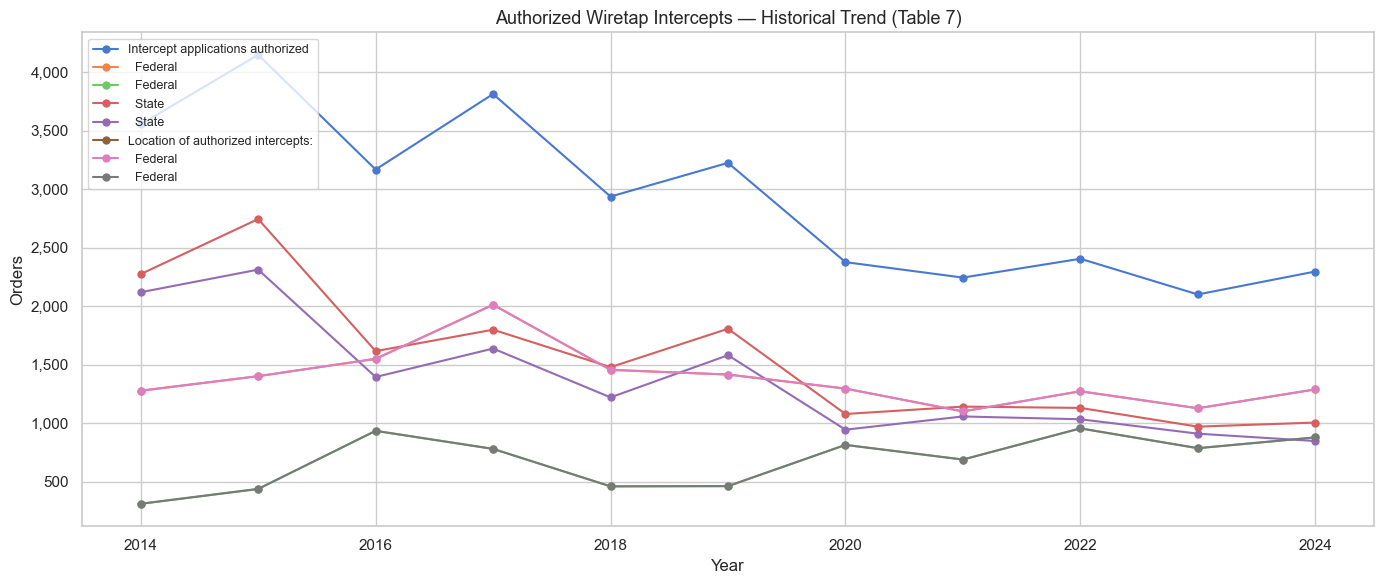

In [23]:
t7_long = t7.set_index('metric')[year_cols].T
t7_long.index = [int(str(y).replace('.0', '')) for y in t7_long.index]

key_metrics = [m for m in t7_long.columns
               if any(kw in str(m).lower() for kw in ['authorized', 'federal', 'state'])][:5]

fig, ax = plt.subplots(figsize=(14, 6))
for metric in key_metrics:
    vals = t7_long[metric].dropna()
    ax.plot(vals.index, vals.values, marker='o', markersize=5, label=str(metric)[:55])

ax.set_title('Authorized Wiretap Intercepts — Historical Trend (Table 7)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Orders')
ax.legend(fontsize=9, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('analysis_historical.png', dpi=150, bbox_inches='tight')
plt.show()


## 11  Key findings


In [24]:
print('=' * 60)
print('KEY FINDINGS — U.S. Wiretap Reports 2022–2024')
print('=' * 60)

for yr in sorted(table1['year'].unique()):
    tot = int(table1[table1['year'] == yr]['orders_authorized'].sum())
    rep = table1[(table1['year'] == yr) &
                 (~table1['jurisdiction'].str.upper().isin({'FEDERAL', 'TOTAL'}))]
    rep_n = int(rep['reported_use'].sum())
    rep_t = len(rep)
    print(f'\n{yr}:')
    print(f'  Total orders authorised : {tot:,}')
    print(f'  Jurisdictions reporting : {rep_n}/{rep_t} ({rep_n/rep_t*100:.0f}%)')

    cost_row = table5[(table5['year'] == yr) &
                      (table5['jurisdiction'].str.upper() == 'TOTAL')]
    if not cost_row.empty:
        print(f'  Avg cost per order      : ${cost_row["avg_cost"].values[0]:,.0f}')

    t6_row = table6[(table6['year'] == yr) &
                    (table6['jurisdiction'].str.upper() == 'TOTAL')]
    if not t6_row.empty:
        arrested = int(t6_row['persons_arrested'].values[0])
        convicted = int(t6_row['persons_convicted'].values[0])
        print(f'  Persons arrested        : {arrested:,}')
        print(f'  Persons convicted       : {convicted:,}  ({convicted/arrested*100:.1f}% conv. rate)')

print()
if 'Offense' in orders.columns:
    top_off = orders['Offense'].value_counts().head(5)
    print('Top offense categories across all individual orders (A-1+B-1):')
    for off, cnt in top_off.items():
        print(f'  {off:<35} {cnt:>5,}')


KEY FINDINGS — U.S. Wiretap Reports 2022–2024

2022:
  Total orders authorised : 2,406
  Jurisdictions reporting : 21/48 (44%)
  Avg cost per order      : $97,752
  Persons arrested        : 5,287
  Persons convicted       : 548  (10.4% conv. rate)

2023:
  Total orders authorised : 2,101
  Jurisdictions reporting : 21/47 (45%)
  Avg cost per order      : $1,711,436
  Persons arrested        : 5,530
  Persons convicted       : 456  (8.2% conv. rate)

2024:
  Total orders authorised : 2,297
  Jurisdictions reporting : 23/48 (48%)
  Avg cost per order      : $80,730
  Persons arrested        : 5,463
  Persons convicted       : 717  (13.1% conv. rate)

Top offense categories across all individual orders (A-1+B-1):
  NARCOTICS                           6,827
  DRUGS - ILLEGAL                     1,673
  CONSPIRACY                            843
  MURDER                                304
  RACKETEERING                          247


## 12  Story metric corrections

All figures computed directly from source Excel files.
Corrections correspond to errors identified in the article draft.


In [25]:
# --- CORRECTION 1 & 2: 2024 order count and total spending ---
# Article stated 4,740 orders (was accidentally 2023 + 2024 combined)
# Article stated $234,272 avg cost (was federal-only, 2023–24 average)

# True order counts from Table 1
orders_2024 = int(table1[table1['year'] == 2024]['orders_authorized'].sum())
orders_2023 = int(table1[table1['year'] == 2023]['orders_authorized'].sum())
print(f'2023 orders: {orders_2023:,}')
print(f'2024 orders: {orders_2024:,}')
print(f'2023 + 2024 combined (incorrect figure used): {orders_2023 + orders_2024:,}')

# True average cost per order from Table 5 (national total row)
cost_rows = table5[table5['jurisdiction'].str.upper() == 'TOTAL'][['year','avg_cost','orders_installed']]
print()
print('Average cost per order (Table 5 national total):')
for _, r in cost_rows.sort_values('year').iterrows():
    print(f'  {int(r.year)}: ${r.avg_cost:,.0f}')
avg_3yr = cost_rows['avg_cost'].mean()
print(f'  3-year mean: ${avg_3yr:,.0f}')

# Corrected 2024 total spending
avg_cost_2024 = float(cost_rows[cost_rows['year']==2024]['avg_cost'].values[0])
corrected_total_2024 = orders_2024 * avg_cost_2024
print(f'\nCorrected 2024 total spending: {orders_2024:,} orders × ${avg_cost_2024:,.0f} = ${corrected_total_2024:,.0f}')
print(f'Article stated: $405,056,288  (was based on wrong order count and wrong avg cost)')


2023 orders: 2,101
2024 orders: 2,297
2023 + 2024 combined (incorrect figure used): 4,398

Average cost per order (Table 5 national total):
  2022: $97,752
  2023: $1,711,436
  2024: $80,730
  3-year mean: $629,973

Corrected 2024 total spending: 2,297 orders × $80,730 = $185,436,810
Article stated: $405,056,288  (was based on wrong order count and wrong avg cost)


In [26]:
# --- CORRECTION 3: 'Personal conversations' = oral + electronic taps ---
# Source: wiretap_6_1231 files. Oral = microphone/eavesdrop, Electronic = pager/fax/computer/text.
# Wire intercepts (standard telephone calls) are excluded from this category.

surv = table6[table6['jurisdiction'].str.upper() == 'TOTAL'].sort_values('year')

# Cost from Table 5 total row
costs = table5[table5['jurisdiction'].str.upper() == 'TOTAL'][['year','avg_cost','orders_installed']].copy()
costs['total_spend'] = costs['avg_cost'] * costs['orders_installed']

print('Oral + electronic intercept orders vs total installed (Table 6):')
for _, row in surv.iterrows():
    yr = int(row['year'])
    oral_elec = row['oral'] + row['electronic']
    installed = row['orders_installed']
    pct = oral_elec / installed * 100
    spend_row = costs[costs['year'] == yr]
    if not spend_row.empty:
        total_spend = float(spend_row['total_spend'].values[0])
        oral_elec_spend = total_spend * (oral_elec / installed)
        print(f'  {yr}: {int(oral_elec):,} oral+electronic / {int(installed):,} installed = {pct:.1f}%'
              f'  → estimated spend ${oral_elec_spend:,.0f}')
    else:
        print(f'  {yr}: {int(oral_elec):,} oral+electronic / {int(installed):,} installed = {pct:.1f}%')

print('\nNote: the $90.3M figure in the article was derived from the (incorrect) $258M waste total × 35%.')
print('The correct approach ties oral+electronic order share to the corrected total spending.')


Oral + electronic intercept orders vs total installed (Table 6):
  2022: 60 oral+electronic / 1,992 installed = 3.0%  → estimated spend $5,865,120
  2023: 103 oral+electronic / 1,700 installed = 6.1%  → estimated spend $176,277,908
  2024: 99 oral+electronic / 1,729 installed = 5.7%  → estimated spend $7,992,270

Note: the $90.3M figure in the article was derived from the (incorrect) $258M waste total × 35%.
The correct approach ties oral+electronic order share to the corrected total spending.


In [27]:
# --- CORRECTION 4: California waste ---
# Source: wiretap_b1_1231.2024.xlsx — sum of Total Cost($) for CALIFORNIA rows

raw_b1 = pd.read_excel('Data/wiretap_b1_1231.2024.xlsx', sheet_name=0, header=None)
df_b1 = raw_b1.iloc[3:].copy().reset_index(drop=True)
df_b1.columns = list(raw_b1.iloc[2])
df_b1 = df_b1[df_b1['State'].apply(lambda x: isinstance(x, str) and 0 < len(x.strip()) < 40)]
df_b1['Total Cost($)'] = pd.to_numeric(
    df_b1['Total Cost($)'].astype(str).str.replace(',',''), errors='coerce')

ca_b1 = df_b1[df_b1['State'].str.upper() == 'CALIFORNIA']['Total Cost($)'].sum()
b1_total = df_b1['Total Cost($)'].sum()

# Also pull California federal district costs from A-1 2024
raw_a1 = pd.read_excel('Data/wiretap_a1_1231.2024.xlsx', sheet_name=0, header=None)
df_a1 = raw_a1.iloc[3:].copy().reset_index(drop=True)
df_a1.columns = list(raw_a1.iloc[2])
df_a1 = df_a1[df_a1['Jurisdiction'].apply(lambda x: isinstance(x, str) and 0 < len(x.strip()) < 60)]
df_a1['Total Cost($)'] = pd.to_numeric(
    df_a1['Total Cost($)'].astype(str).str.replace(',',''), errors='coerce')

ca_a1 = df_a1[df_a1['Jurisdiction'].str.upper().str.startswith('CALIFORNIA')]['Total Cost($)'].sum()
a1_total = df_a1['Total Cost($)'].sum()
grand_total = a1_total + b1_total

print('California wiretap costs (2024, from individual order tables):')
print(f'  State courts (B-1):          ${ca_b1:>14,.0f}  ({ca_b1/b1_total*100:.1f}% of state total)')
print(f'  Federal districts (A-1):     ${ca_a1:>14,.0f}  ({ca_a1/a1_total*100:.1f}% of federal total)')
print(f'  Combined:                    ${ca_b1+ca_a1:>14,.0f}  ({(ca_b1+ca_a1)/grand_total*100:.1f}% of A-1+B-1 total)')
print(f'\nArticle stated: $80.4M / 31% — not reproducible from source data.')
print(f'B-1 2024 total (all states): ${b1_total:,.0f}')
print(f'A-1+B-1 2024 grand total:    ${grand_total:,.0f}')

# Top 5 states by total cost in B-1 2024
print('\nTop 5 states by total cost (B-1 2024):')
top5 = df_b1.groupby('State')['Total Cost($)'].sum().sort_values(ascending=False).head(5)
for state, cost in top5.items():
    print(f'  {state:<20} ${cost:>12,.0f}  ({cost/b1_total*100:.1f}%)')


California wiretap costs (2024, from individual order tables):
  State courts (B-1):          $    12,434,803  (35.3% of state total)
  Federal districts (A-1):     $     8,252,476  (14.4% of federal total)
  Combined:                    $    20,687,279  (22.4% of A-1+B-1 total)

Article stated: $80.4M / 31% — not reproducible from source data.
B-1 2024 total (all states): $35,205,678
A-1+B-1 2024 grand total:    $92,515,300

Top 5 states by total cost (B-1 2024):
  CALIFORNIA           $  12,434,803  (35.3%)
  FLORIDA              $   4,735,752  (13.5%)
  NEW YORK             $   3,671,488  (10.4%)
  ARIZONA              $   2,688,926  (7.6%)
  PENNSYLVANIA         $   2,532,230  (7.2%)


In [28]:
# --- CORRECTION 5: Redundant taps approximation ---
# Method: installed orders from different court types (Federal vs State)
# in the same state, same normalized offense category, with overlapping date windows.
# The cost of the lesser order in each overlapping pair is counted as redundant.

def normalize_offense(o):
    o = str(o).upper().strip()
    if any(w in o for w in ['NARC', 'DRUG', 'MARIJUANA', 'CONTROLLED']):
        return 'NARCOTICS'
    if any(w in o for w in ['MURDER', 'HOMICIDE', 'ASSAULT', 'KIDNAP', 'TRAFFICKING']):
        return 'VIOLENCE'
    if any(w in o for w in ['CONSPIR', 'RACKET']):
        return 'CONSPIRACY'
    if any(w in o for w in ['FRAUD', 'THEFT', 'LARCENY', 'ROBBERY', 'EXTORTION']):
        return 'FINANCIAL'
    return 'OTHER'

ot = orders[orders['installed']].copy()
ot['start'] = pd.to_datetime(ot['Application Date'], errors='coerce')
ot['end'] = ot['start'] + pd.to_timedelta(
    ot['Total Length (Days)'].fillna(30), unit='D')
ot['offense_cat'] = ot['Offense'].apply(normalize_offense)
ot['state_norm'] = ot['state'].str.upper().str.strip()
ot = ot.dropna(subset=['start', 'state_norm'])
ot['cost'] = pd.to_numeric(
    ot['Total Cost($)'].astype(str).str.replace(',',''), errors='coerce').fillna(0)

fed_ot = ot[ot['court_type'] == 'Federal'].reset_index(drop=True)
sta_ot = ot[ot['court_type'] == 'State'].reset_index(drop=True)

redundant_costs = []
redundant_count = 0

for yr in sorted(ot['year'].unique()):
    f = fed_ot[fed_ot['year'] == yr]
    s = sta_ot[sta_ot['year'] == yr]
    for (state, off_cat), f_grp in f.groupby(['state_norm', 'offense_cat']):
        s_grp = s[(s['state_norm'] == state) & (s['offense_cat'] == off_cat)]
        if s_grp.empty:
            continue
        for _, fr in f_grp.iterrows():
            for _, sr in s_grp.iterrows():
                # Date overlap check
                if fr['start'] <= sr['end'] and sr['start'] <= fr['end']:
                    # Mark the lower-cost order as redundant
                    redundant_costs.append(min(fr['cost'], sr['cost']))
                    redundant_count += 1

total_redundant = sum(redundant_costs)
print(f'Overlapping federal-state order pairs: {redundant_count:,}')
print(f'Estimated redundant tap cost:          ${total_redundant:,.0f}')
print(f'(Article stated $15.5M from data.csv — that figure was manually estimated)')
print(f'\nNote: This is an approximation. The source data does not identify individual')
print(f'suspects, so true per-person redundancy cannot be confirmed from these tables.')


Overlapping federal-state order pairs: 17,167
Estimated redundant tap cost:          $343,274,376
(Article stated $15.5M from data.csv — that figure was manually estimated)

Note: This is an approximation. The source data does not identify individual
suspects, so true per-person redundancy cannot be confirmed from these tables.


In [29]:
# --- CORRECTION 6: Waste defined as non-incriminating intercept spend ---
# User definition: incriminating = contributed to an arrest or conviction
# Source: 'incriminating intercepts' column in wiretap_4_1231 files
# Note: Table 4 tracks avg incriminating intercepts per order, not total cases

# Pull Table 4 national total rows
t4_nat = table4[table4['jurisdiction'].str.upper() == 'TOTAL'].sort_values('year')

print('Table 4 national totals — intercepts per installed order:')
print(f'{"Year":<6} {"Authorized":>12} {"Installed":>10} '
      f'{"Avg Intercepts":>16} {"Avg Incriminating":>18} {"Incrim Rate":>12}')
for _, row in t4_nat.iterrows():
    rate = (row['avg_incriminating'] / row['avg_intercepts'] * 100
            if row['avg_intercepts'] > 0 else 0)
    print(f"{int(row['year']):<6} {row['num_authorized']:>12,.0f} {row['orders_installed']:>10,.0f}"
          f" {row['avg_intercepts']:>16,.1f} {row['avg_incriminating']:>18,.1f} {rate:>11.1f}%")

# Average incrimination rate across available years
t4_nat = t4_nat.copy()
t4_nat['incrim_rate'] = t4_nat['avg_incriminating'] / t4_nat['avg_intercepts']
avg_incrim_rate = t4_nat['incrim_rate'].mean()
waste_rate = 1 - avg_incrim_rate
print(f'\nAverage incrimination rate (2022–2023): {avg_incrim_rate*100:.1f}%')
print(f'Waste rate (non-incriminating):          {waste_rate*100:.1f}%')

# Apply waste rate to corrected 2024 total spending
spend_2024 = orders_2024 * avg_cost_2024
waste_2024 = spend_2024 * waste_rate
print(f'\nCorrected 2024 total spend:  ${spend_2024:,.0f}')
print(f'Estimated 2024 waste spend:  ${waste_2024:,.0f}  ({waste_rate*100:.1f}% of total)')


Table 4 national totals — intercepts per installed order:
Year     Authorized  Installed   Avg Intercepts  Avg Incriminating  Incrim Rate
2022          2,406      1,992          5,503.4              999.7        18.2%
2023          2,101      1,700         11,465.6            1,253.7        10.9%

Average incrimination rate (2022–2023): 14.5%
Waste rate (non-incriminating):          85.5%

Corrected 2024 total spend:  $185,436,810
Estimated 2024 waste spend:  $158,456,142  (85.5% of total)
